# BBlean
## BitBIRCH for binary fingerprints (memory-efficient)

Authors:
- Kenneth Lopez-Perez (klopezperez@chem.ufl.edu)
- Ramon Alain Miranda-Quintana (quintana@chem.ufl.edu)

This notebook contains simple examples on how to use `iChem.bblean`. It demonstrates generating binary fingerprints, estimating a BitBirch threshold, fitting a `BitBirch` tree, and basic visualization.

### Imports

We import `BitBirch` from `iChem.bblean`, fingerprint utilities from `iChem.utils`, and visualization helpers.

In [ ]:
# Core bblean classes and helpers
from iChem.bitbirch import cluster, optimal_threshold

# Fingerprint and IO utilities
from iChem.utils import binary_fps, load_smiles
from iChem.visualization.mol_images import smiles_to_grid_image
from iChem.visualization.plots import clusters_pop_plot, clusters_pop_isim_plot
from iChem.visualization.cluster_connect import cluster_connections

# Other
import numpy as np

# Profiling
import tracemalloc


# Fingerprint generation

We will load a SMILES file and generate packed binary fingerprints for BitBirch.

In [2]:
smiles = load_smiles('../tests/data/mcule_natural_products.smi')

In [3]:
# Generate packed binary fingerprints (packed=True returns bytes per row)
fps, invalid_smiles = binary_fps(smiles,
                                fp_type='ECFP4',  # options: 'AP', 'ECFP4', 'RDKIT', 'ECFP6', 'TT', 'MACCS'
                                n_bits=1024,
                                return_invalid=True,
                                packed=True)

if invalid_smiles:
    print(f"Invalid SMILES found: {invalid_smiles}")
    print("These will be ignored for clustering.")

For memory efficiency during the clustering stage, please save the fingerprints to disk.

In [4]:
np.save('test_fps.npy', fps)

# Estimate clustering threshold

For binary fingerprints we use `optimal_threshold` from `iChem.bblean.similarity`.

In [5]:
# Estimate iSIM-based threshold (packed=True)
bb_threshold = optimal_threshold(fps, packed=True, factor=3.5)
print(f"Recommended threshold: {bb_threshold:.4f}")

Recommended threshold: 0.3440


# Fit BitBirch

We fit a `BitBirch` tree using the recommended threshold. For packing we pass the fingerprints directly (packed array).

In [6]:
tracemalloc.start()

clustered_ids = cluster('test_fps.npy',
                       threshold=bb_threshold,
                       branching_factor=10_000)

print(f"Memory usage after fitting: {tracemalloc.get_traced_memory()[0] / 1e6:.2f} MB")
print(f"Peak memory usage during fitting: {tracemalloc.get_traced_memory()[1] / 1e6:.2f} MB")

Number of molecules in the file: 23327
Using sequential clustering for the file.
Memory usage after fitting: 5.51 MB
Peak memory usage during fitting: 7.57 MB


# Analysis of clustering results

Plot cluster populations and iSIM summary for top clusters.

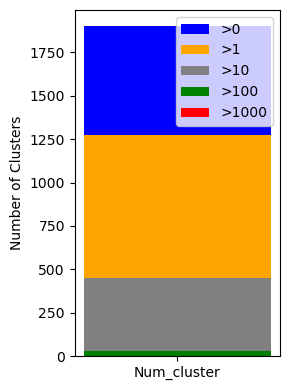

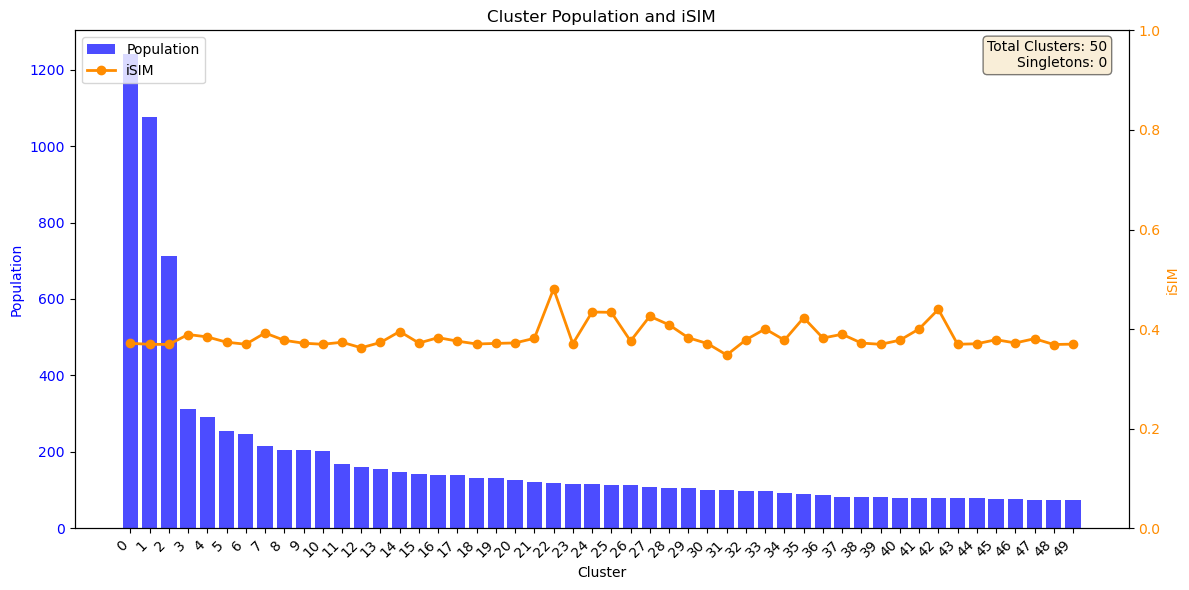

In [8]:
clusters_pop_plot(clustered_ids)

clusters_pop_isim_plot(clustered_ids, fps, top=50)

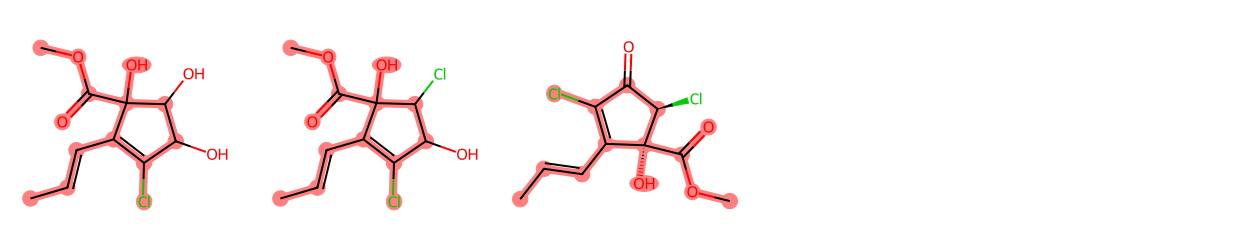

In [21]:
# Visualize molecules from a chosen cluster
k = 999  # change to a cluster index you want to inspect

smiles_to_grid_image([smiles[i] for i in clustered_ids[k]],
                     MSC = True)
